In [1]:
import argparse
import os
import random
import torch
import numpy as np
from utils.stereo import stereo, attack_stereo
from utils.utils import StableDiffuser
import torch.nn.functional as F

/home/bright/miniconda3/envs/stereo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/bright/miniconda3/envs/stereo/lib/python3.9/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/bright/miniconda3/envs/stereo/lib/python3.9/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")


In [2]:
def subspace_elimination_loss(target_embeddings, reference_embeddings, finetuner):
    ft_modules = finetuner.ft_modules

    total_projected_loss = 0.0
    total_reg_loss = 0.0

    for key,param in ft_modules.items():
        if 'to_k' in key or 'to_v' in key:
            weight = param.weight

            target_projected = (target_embeddings @ weight.T).transpose(1, 2) # [bsz, d, num_tokens]
            reference_projected = (reference_embeddings @ weight.T).transpose(1, 2) # [bsz, d, num_tokens]

            # Compute projection matrix: R @ (R^T @ R)^(-1) @ R^T
            # P = R @ inv(R^T @ R) @ R^T
            gram_inv = torch.inverse(
                torch.bmm(
                    reference_projected.transpose(1, 2),  # [bsz, d, num_tokens]
                    reference_projected  # [bsz, num_tokens, d]
                ).transpose(1, 2)  # [bsz, num_tokens, num_tokens]
            )  # [bsz, num_tokens, num_tokens]

            projection_matrix = torch.bmm(
                torch.bmm(reference_projected, gram_inv),  # [bsz, num_tokens, num_tokens]
                reference_projected.transpose(1, 2)  # [bsz, d, num_tokens]
            )  # [bsz, d, d]

            target_projected_onto_ref = torch.bmm(
                projection_matrix,  # [bsz, d, d]
                target_projected  # [bsz, d, num_tokens]
            )  # [bsz, d, num_tokens]

            ref_projected_onto_ref = torch.bmm(
                projection_matrix,  # [bsz, d, d]
                reference_projected  # [bsz, d, num_tokens]
            )  # [bsz, d, num_tokens]

            projection_loss = F.mse_loss(target_projected_onto_ref, target_projected, reduction="mean")
            regularization_loss = F.mse_loss(ref_projected_onto_ref, reference_projected, reduction="mean")

            total_projected_loss += projection_loss
            total_reg_loss += regularization_loss

    return total_projected_loss / len(ft_modules), total_reg_loss / len(ft_modules)


def new_encode_text(diffuser, tokens):
    return diffuser.text_encoder(tokens.to(diffuser.unet.device))[0]

def subspace_elimination(
    args,
    train_dataloader,
    train_method,
    epochs,
    iterations,
    lr,
    save_path, diffuser, device):

    # Set the random seed for reproducibility
    seed = 42
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

    diffuser.requires_grad = True
    diffuser.train()

    finetuner = FineTunedModel(diffuser, train_method=train_method)
    optimizer = torch.optim.Adam(finetuner.parameters(), lr=lr)

    # Initialize Progress Bar
    pbar = tqdm(total=iterations, desc="Training")
    global_step = 0

    for epoch in range(epochs):
        for step, batch in enumerate(train_dataloader):
            if global_step >= iterations:
                break

            optimizer.zero_grad()

            # Encode the images to latent space
            latents = diffuser.encode(batch["pixel_values"].to(device))
            noise = torch.randn_like(latents).to(device)
            bsz = latents.shape[0]

            # Sample a random timestep
            timesteps = torch.randint(
                0, diffuser.scheduler.config.num_train_timesteps, (bsz,), device=latents.device
            ).long()

            # Add noise (Forward diffusion)
            # print(latents.device, noise.device, timesteps.device)
            noisy_latents = diffuser.add_noise(latents, noise, timesteps)

            # Get the text embedding
            encoder_hidden_states = diffuser.text_encode(batch["input_ids"].to(device))
            encoder_anchor_hidden_states = diffuser.text_encode(batch["input_anchor_ids"].to(device))
            # encoder_hidden_states = new_encode_text(diffuser, batch["input_ids"].to(device)) 
            # encoder_anchor_hidden_states = new_encode_text(diffuser, batch["input_anchor_ids"].to(device))
            
            # Get the text embedding of the target
            bsz, num_target_tokens, token_length = batch["target_prompt_ids"].input_ids.shape

            batch["target_prompt_ids"].input_ids = batch["target_prompt_ids"].input_ids.reshape(bsz * num_target_tokens, -1).to(device)
            encoder_target_hidden_states = diffuser.text_encode(batch["target_prompt_ids"]).reshape(bsz, num_target_tokens, token_length, -1) # Shape [bsz,num_tokens,77,768]
            # print("encoder_target_hidden_states",encoder_target_hidden_states.shape)
            # encoder_target_hidden_states =  new_encode_text(diffuser, batch["target_prompt_ids"].reshape(bsz * num_target_tokens, -1).to(device)).reshape(bsz, num_target_tokens, token_length, -1)  # Shape [bsz,num_tokens,77,768]
            # Get the text embedding of the reference
            batch["reference_prompt_ids"].input_ids = batch["reference_prompt_ids"].input_ids.reshape(bsz * num_target_tokens, -1).to(device)
            encoder_reference_hidden_states = diffuser.text_encode(batch["reference_prompt_ids"]).reshape(bsz, num_target_tokens, token_length, -1) # Shape [bsz,num_tokens,77,768]
            # print("encoder_reference_hidden_states",encoder_reference_hidden_states.shape)
            # encoder_reference_hidden_states =   new_encode_text(diffuser, batch["reference_prompt_ids"].reshape(bsz * num_target_tokens, -1).to(device)).reshape(bsz, num_target_tokens, token_length, -1) # Shape [bsz,num_tokens,77,768]


            # print(encoder_target_hidden_states)
            # print(encoder_reference_hidden_states)
            # print(abs(encoder_target_hidden_states-encoder_reference_hidden_states).mean())
            # Get the index of target and reference
            target_indices = batch["target_indices"].to(device) # Shape [bsz,num_tokens]
            reference_indices = batch["reference_indices"].to(device) # Shape [bsz,num_tokens]
            # Expand indices to match the embedding dimension
            target_idx_expanded = target_indices.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, 1, encoder_target_hidden_states.shape[-1])
            reference_idx_expanded = reference_indices.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, 1, encoder_reference_hidden_states.shape[-1])

            # Gather the embeddings at specified indices
            target_embeddings = encoder_target_hidden_states.gather(2, target_idx_expanded).squeeze(2)  # [bsz, num_tokens, 768]
            # print(target_embeddings.shape)
            reference_embeddings = encoder_reference_hidden_states.gather(2, reference_idx_expanded).squeeze(2)  # [bsz, num_tokens, 768]
            # print(reference_embeddings.shape)

            # print(target_embeddings)
            # print(reference_embeddings)
            

            # Subspace Elimination Loss
            projected_loss, reg_loss = subspace_elimination_loss(target_embeddings, reference_embeddings, finetuner)
            suma_loss = projected_loss + reg_loss
            # loss = suma_loss
            # loss.backward()

            ## Concept Abalation Loss
            # Predict the noise residual
            with finetuner:
                # print(noisy_latents.shape, timesteps.shape, encoder_hidden_states.shape)
                model_pred = diffuser.unet(noisy_latents, timesteps, encoder_hidden_states).sample

            print('1!!!',noisy_latents.shape)
            print('2!!!',encoder_anchor_hidden_states.size(0))
            print('3!!!',noisy_latents[: encoder_anchor_hidden_states.size(0)].shape)
            with torch.no_grad():
                # with finetuner: # our change
                    # Anchor prediction for ablation
                model_pred_anchor = diffuser.unet(
                    noisy_latents[: encoder_anchor_hidden_states.size(0)],
                    timesteps[: encoder_anchor_hidden_states.size(0)],
                    encoder_anchor_hidden_states,
                ).sample

            # Determine Target
            target = model_pred_anchor
            if args.with_prior_preservation:
                _, target_prior = torch.chunk(noise, 2, dim=0) # Use actual noise as prior target


            # Loss Calculation
            if args.with_prior_preservation:
                model_pred, model_pred_prior = torch.chunk(model_pred, 2, dim=0)
                mask = torch.chunk(batch["mask"], 2, dim=0)[0]

                # Instance loss with mask
                loss = F.mse_loss(model_pred.float(), target.float(), reduction="none")
                loss = ((loss * mask).sum([1, 2, 3]) / mask.sum([1, 2, 3])).mean()

                # Prior loss
                prior_loss = F.mse_loss(model_pred_prior.float(), target_prior.float(), reduction="mean")
                loss = loss + args.prior_loss_weight * prior_loss
            else:
                # mask = batch["mask"].to(device)
                loss = F.mse_loss(model_pred.float(), target.float(), reduction="none").mean()
                print(loss.item())
                # print(loss.item())
                # loss = ((loss * mask).sum([1, 2, 3]) / mask.sum([1, 2, 3])).mean()
                # loss = ((loss).sum([1, 2, 3]) / mask.sum([1, 2, 3])).mean()

            loss = loss + suma_loss
            loss.backward()

            optimizer.step()

            # print(finetuner.parameters()[0])

            # Update progress bar
            global_step += 1
            pbar.update(1)
            pbar.set_description(f"Epoch {epoch} Loss: {loss.item():.4f}, Projected Loss: {projected_loss.item():.4f}, Regularization Loss: {reg_loss.item():.4f}")

        if global_step >= iterations:
            break

    pbar.close()


    # diffuser.eval()
    return  finetuner

In [3]:
from argparse import Namespace

args = Namespace(
    erase_concept="David Beckham",
    train_method="xattn-kv",
    iterations=200,
    negative_guidance=2.0,
    ste_lr=0.5e-5,
    reo_lr=2e-5,
    ci_lr=5e-3,
    ti_max_train_steps=3000,
    train_data_dir="data/images/train/David_Beckham/",
    learnable_property="person",
    initializer_token="person",
    device="cuda",
    n_iterations=2,
    output_dir="stereo_weights_mine/David_Beckham/",
    generic_prompt="a photo of a",
    anchor_concept_path="utils/anchor_prompts.json",
    compositional_guidance_scale=2.0,
    mode="stereo", #"both",
    unet_ckpt_to_attack="final_reo_unet.pt",
    attack_eval_images="data/images/eval/David_Beckham/",
    center_crop=False,
    num_of_adv_concepts=2,
    with_prior_preservation=False
)

In [4]:
os.makedirs(args.output_dir, exist_ok=True)

# Set the random seed for reproducibility
seed = 42
np.random.seed(seed)      # For numpy
random.seed(seed)         # For the random module
torch.manual_seed(seed)   # For PyTorch

# For CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you have multiple GPUs

# Ensure PyTorch operations are deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# stereo(args)
# # diffuser = StableDiffuser(scheduler='DDIM').to(args.device)

In [6]:
from utils.utils import *
from utils.dataset import TextualInversionDataset
from utils.apg import *
from torch.utils.data import DataLoader

In [7]:
# Perform textual inversion with the erased model to attack
# diffuser = StableDiffuser(scheduler='DDIM').to(args.device)

In [8]:
ckpt = torch.load('stereo_weights_mine/David_Beckham/ste_stage_model.pt', map_location="cpu")
model_state_dict = ckpt["model_state_dict"]
saved_tokens = ckpt["saved_tokens"]

/tmp/ipykernel_634/3562414972.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('stereo_weights_mine/David_Beckham/ste_stage_model.pt', map_location="cpu

In [9]:
import copy

In [10]:
# saved_tokens['0']

In [11]:
diffuser = StableDiffuser(scheduler='DDIM').to(args.device)

clone_tokenizer =  copy.deepcopy(diffuser.tokenizer)
clone_text_encoder =  copy.deepcopy(diffuser.text_encoder)
reference = []
for i in range(3):
    torch.cuda.empty_cache()
    i_name = str(i)
    state_dict = torch.load(f'stereo_weights_mine/David_Beckham/ci_attack_text_encoder_iteration_{i_name}_early.pt', map_location="cuda")
    num_added_tokens = clone_tokenizer.add_tokens([saved_tokens[i_name]])
    clone_text_encoder.resize_token_embeddings(len(clone_tokenizer))
    clone_text_encoder.load_state_dict(state_dict)
    ids = clone_tokenizer.convert_tokens_to_ids([saved_tokens[i_name]])[0]
    latent = clone_text_encoder.get_input_embeddings().weight.data.clone()[ids].cpu().detach().numpy()
    reference.append(latent)
reference = np.stack(reference)

clone_tokenizer =  copy.deepcopy(diffuser.tokenizer)
clone_text_encoder =  copy.deepcopy(diffuser.text_encoder)
target = []
for i in range(3):
    torch.cuda.empty_cache()
    i_name = str(i)
    state_dict = torch.load(f'stereo_weights_mine/David_Beckham/ci_attack_text_encoder_iteration_{i_name}.pt', map_location="cuda")
    num_added_tokens = clone_tokenizer.add_tokens([saved_tokens[i_name]])
    clone_text_encoder.resize_token_embeddings(len(clone_tokenizer))
    clone_text_encoder.load_state_dict(state_dict)
    ids = clone_tokenizer.convert_tokens_to_ids([saved_tokens[i_name]])[0]
    latent = clone_text_encoder.get_input_embeddings().weight.data.clone()[ids].cpu().detach().numpy()
    target.append(latent)
target = np.stack(target)

clone_tokenizer =  copy.deepcopy(diffuser.tokenizer)
clone_text_encoder =  copy.deepcopy(diffuser.text_encoder)

placeholder_tokens = [saved_tokens[str(i)]+'_early' for i in range(3)] + [saved_tokens[str(i)]+'_last' for i in range(3)]
num_added_tokens = clone_tokenizer.add_tokens(placeholder_tokens)
# placeholder_token_ids = clone_tokenizer.convert_tokens_to_ids(placeholder_tokens)
clone_text_encoder.resize_token_embeddings(len(clone_tokenizer))

with torch.no_grad():
    token_embeds = clone_text_encoder.get_input_embeddings().weight.data
    for i in range(3):
        token_name = saved_tokens[str(i)]+'_last'
        placeholder_token_id = clone_tokenizer.convert_tokens_to_ids([token_name])[0]
        token_embeds[placeholder_token_id] = torch.Tensor(target[i]).clone().to(token_embeds.device)
        
    for i in range(3):
        token_name = saved_tokens[str(i)]+'_early'
        placeholder_token_id = clone_tokenizer.convert_tokens_to_ids([token_name])[0]
        token_embeds[placeholder_token_id] = torch.Tensor(reference[i]).clone().to(token_embeds.device)
        
diffuser.tokenizer = copy.deepcopy(clone_tokenizer)
diffuser.text_encoder = copy.deepcopy(clone_text_encoder)
del clone_tokenizer, clone_text_encoder
torch.cuda.empty_cache()


/home/bright/miniconda3/envs/stereo/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/home/bright/miniconda3/envs/stereo/lib/python3.9/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(
/tmp/ipykernel_634/3868541629.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://git

In [12]:
# diffuser.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_k.weight

In [13]:
# generator = torch.manual_seed(0)
# img = diffuser("David Beckham",generator=generator)
# plt.imshow(img[0][0])
# plt.show()

In [14]:
placeholder_tokens

['token_xaji0y6d_early',
 'token_c56t4ufe_early',
 'token_l6246hid_early',
 'token_xaji0y6d_last',
 'token_c56t4ufe_last',
 'token_l6246hid_last']

/home/bright/workspace/robust-concept-erasing/utils/utils.py:148: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (batch_size, self.unet.in_channels, img_size // 8, img_size // 8),
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  6.04it/s]


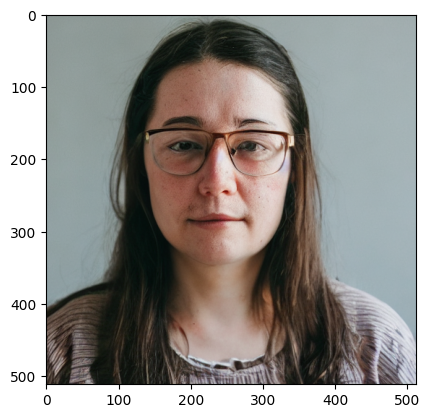

In [15]:
ttt = "a photo portrait of {}".format("person")
img = diffuser(ttt)
plt.imshow(img[0][0])
plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.36it/s]


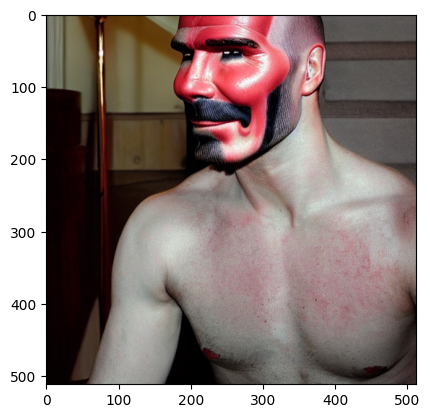

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.37it/s]


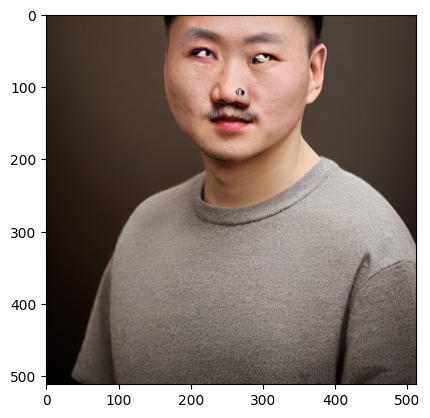

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.36it/s]


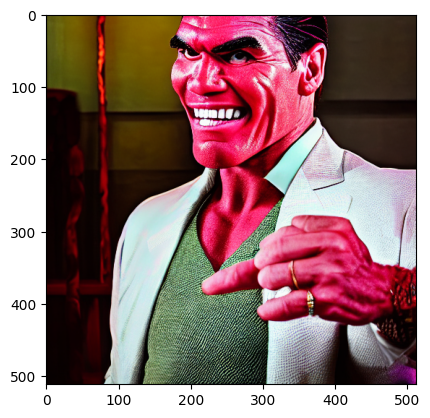

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.36it/s]


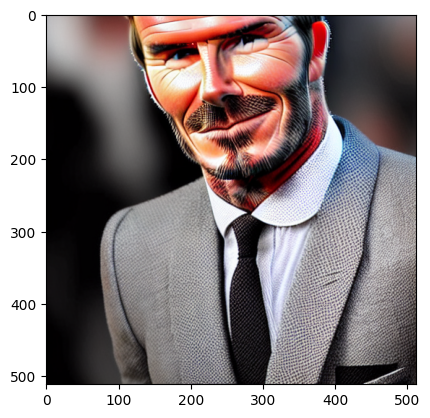

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.36it/s]


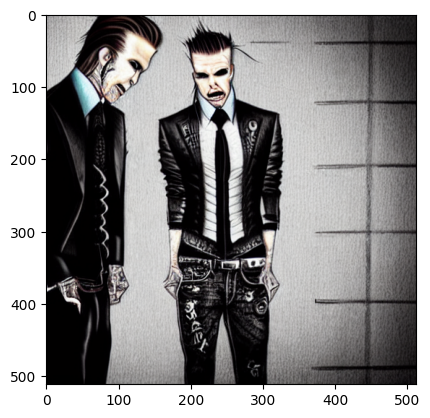

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.35it/s]


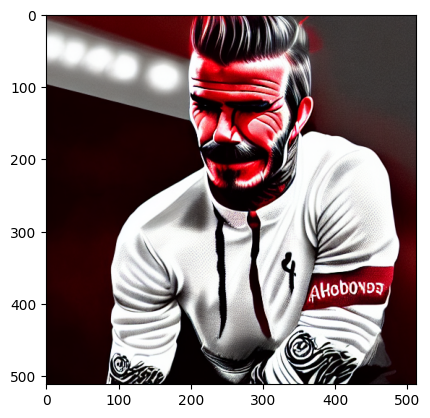

In [16]:
for i in range(6):
    generator = torch.manual_seed(0)
    ttt = "a photo portrait of {}".format(placeholder_tokens[i])
    img = diffuser(ttt,generator=generator)
    plt.imshow(img[0][0])
    plt.show()

In [17]:
placeholder_token_ids = diffuser.tokenizer.convert_tokens_to_ids(placeholder_tokens)

In [18]:
placeholder_tokens

['token_xaji0y6d_early',
 'token_c56t4ufe_early',
 'token_l6246hid_early',
 'token_xaji0y6d_last',
 'token_c56t4ufe_last',
 'token_l6246hid_last']

In [19]:
# text_embeddingss = []
# for i in range(6):
#     text = "a person name "+placeholder_tokens[i]
#     text_tokens = diffuser.text_tokenize(text)
#     text_embeddings = diffuser.text_encode(text_tokens)
#     text_embeddingss.append(text_embeddings)

In [20]:
# text_tokens = diffuser.text_tokenize(text)
# print(text_tokens)
# text_embeddings = diffuser.text_encode(text_tokens)

In [ ]:
import PIL
import os
import random
import torch
import numpy as np
from PIL import Image
from packaging import version
from torch.utils.data import Dataset
from torchvision import transforms


if version.parse(version.parse(PIL.__version__).base_version) >= version.parse("9.1.0"):
    PIL_INTERPOLATION = {
        "linear": PIL.Image.Resampling.BILINEAR,
        "bilinear": PIL.Image.Resampling.BILINEAR,
        "bicubic": PIL.Image.Resampling.BICUBIC,
        "lanczos": PIL.Image.Resampling.LANCZOS,
        "nearest": PIL.Image.Resampling.NEAREST,
    }
else:
    PIL_INTERPOLATION = {
        "linear": PIL.Image.LINEAR,
        "bilinear": PIL.Image.BILINEAR,
        "bicubic": PIL.Image.BICUBIC,
        "lanczos": PIL.Image.LANCZOS,
        "nearest": PIL.Image.NEAREST,
    }


# Define prompt templates
imagenet_templates_small = [
    "a photo of a {}",
    "a rendering of a {}",
    "a cropped photo of the {}",
    "the photo of a {}",
    "a photo of a clean {}",
    "a photo of a dirty {}",
    "a dark photo of the {}",
    "a photo of my {}",
    "a photo of the cool {}",
    "a close-up photo of a {}",
    "a bright photo of the {}",
    "a cropped photo of a {}",
    "a photo of the {}",
    "a good photo of the {}",
    "a photo of one {}",
    "a close-up photo of the {}",
    "a rendition of the {}",
    "a photo of the clean {}",
    "a rendition of a {}",
    "a photo of a nice {}",
    "a good photo of a {}",
    "a photo of the nice {}",
    "a photo of the small {}",
    "a photo of the weird {}",
    "a photo of the large {}",
    "a photo of a cool {}",
    "a photo of a small {}",
]

imagenet_style_templates_small = [
    "a painting in the style of {}",
    "a rendering in the style of {}",
    "a cropped painting in the style of {}",
    "the painting in the style of {}",
    "a clean painting in the style of {}",
    "a dirty painting in the style of {}",
    "a dark painting in the style of {}",
    "a picture in the style of {}",
    "a cool painting in the style of {}",
    "a close-up painting in the style of {}",
    "a bright painting in the style of {}",
    "a cropped painting in the style of {}",
    "a good painting in the style of {}",
    "a close-up painting in the style of {}",
    "a rendition in the style of {}",
    "a nice painting in the style of {}",
    "a small painting in the style of {}",
    "a weird painting in the style of {}",
    "a large painting in the style of {}",
]

person_templates_small = [
    "a photo portrait of {}",
    "a DSLR portrait of {}",
]

class TextualInversionDataset_mine(Dataset):
    def __init__(
        self,
        data_root,
        tokenizer,
        learnable_property="object",  # [object, style]
        size=512,
        repeats=100,
        interpolation="bicubic",
        flip_p=0.5,
        set="train",
        placeholder_token="*",
        center_crop=False,
        iteration=None,       # New argument for the iteration
        num_iterations=None,   # New argument for the number of images per subset
        generic="person",
        erase="David Beckham",
    ):
        self.erase = erase
        self.generic = generic
        self.data_root = data_root
        self.tokenizer = tokenizer
        self.learnable_property = learnable_property
        self.size = size
        self.placeholder_token = placeholder_token
        self.center_crop = center_crop
        self.flip_p = flip_p
        self.iteration = iteration
        self.num_iterations = num_iterations

        self.image_paths = [os.path.join(self.data_root, file_path) for file_path in os.listdir(self.data_root)]
        self.num_images = len(self.image_paths)

        # Dynamically calculate images_per_subset based on total images and number of iterations
        self.images_per_subset = max(1, self.num_images // self.num_iterations)

        # Partition image paths into non-overlapping subsets based on iteration and images_per_subset
        start_idx = (self.iteration * self.images_per_subset) % self.num_images
        end_idx = start_idx + self.images_per_subset
        if end_idx <= self.num_images:
            self.subset_image_paths = self.image_paths[start_idx:end_idx]
        else:
            # Wrap around if end_idx exceeds the number of images
            self.subset_image_paths = self.image_paths[start_idx:] + self.image_paths[:end_idx - self.num_images]

        self._length = len(self.subset_image_paths) * repeats if set == "train" else len(self.subset_image_paths)

        if set == "train":
            self._length = self.num_images * repeats

        self.interpolation = {
            "linear": PIL_INTERPOLATION["linear"],
            "bilinear": PIL_INTERPOLATION["bilinear"],
            "bicubic": PIL_INTERPOLATION["bicubic"],
            "lanczos": PIL_INTERPOLATION["lanczos"],
        }[interpolation]

        if learnable_property == "object":
            self.templates = imagenet_templates_small
        elif learnable_property == "style":
            print(f"Using learnable property : {learnable_property}")
            self.templates = imagenet_style_templates_small
        elif learnable_property == "person":
            self.templates = person_templates_small

        self.flip_transform = transforms.RandomHorizontalFlip(p=self.flip_p)

    def __len__(self):
        return self._length

    def __getitem__(self, i):
        example = {}

        # Ensure the subset is non-overlapping by using subset_image_paths
        image_path = self.subset_image_paths[i % len(self.subset_image_paths)]
        image = Image.open(image_path)

        if not image.mode == "RGB":
            image = image.convert("RGB")

        placeholder_string = self.placeholder_token
        text = random.choice(self.templates) #.format(placeholder_string)
        text1_early = text.format(placeholder_string[0])
        text2_early = text.format(placeholder_string[1])
        text3_early = text.format(placeholder_string[2])

        text1_last = text.format(placeholder_string[3])
        text2_last = text.format(placeholder_string[4])
        text3_last = text.format(placeholder_string[5])

        text_erase = text.format(self.erase)
        text_generic = text.format(self.generic)
        print(text_erase)
        print(text_generic)

        example["input_ids"] = self.tokenizer(
            # [text1_early,text2_early,text3_early],
            [text_erase],
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )

        example["input_anchor_ids"] = self.tokenizer(
            # [text1_early,text2_early,text3_early],
            [text_generic],
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )

        example["target_prompt_ids"] = self.tokenizer(
            [text1_last,text2_last,text3_last],
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )

        example["reference_prompt_ids"] = self.tokenizer(
            [text1_early,text2_early,text3_early],
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )
        example["target_indices"]  = []
        example["reference_indices"]  = []
        # print(example["target_prompt_ids"].input_ids.shape)
        for i in range(3):
            example["target_indices"].append(torch.where(example["target_prompt_ids"].input_ids[i]==diffuser.tokenizer.convert_tokens_to_ids(placeholder_string[i+3]))[0])
            example["reference_indices"].append(torch.where(example["reference_prompt_ids"].input_ids[i]==diffuser.tokenizer.convert_tokens_to_ids(placeholder_string[i]))[0])

        example["target_indices"] = torch.cat(example["target_indices"]).long()
        example["reference_indices"] = torch.cat(example["reference_indices"]).long()
        # default to score-sde preprocessing
        img = np.array(image).astype(np.uint8)

        if self.center_crop:
            crop = min(img.shape[0], img.shape[1])
            (
                h,
                w,
            ) = (
                img.shape[0],
                img.shape[1],
            )
            img = img[(h - crop) // 2 : (h + crop) // 2, (w - crop) // 2 : (w + crop) // 2]

        image = Image.fromarray(img)
        image = image.resize((self.size, self.size), resample=self.interpolation)

        image = self.flip_transform(image)
        image = np.array(image).astype(np.uint8)
        image = (image / 127.5 - 1.0).astype(np.float32)

        example["pixel_values"] = torch.from_numpy(image).permute(2, 0, 1)
        return example

In [ ]:
def get_dataloader(
    diffuser,
    train_data_dir, 
    lr, 
    device, 
    num_vectors=1, 
    max_train_steps=3000,  # Total training steps across all epochs
    resolution=512, 
    learnable_property="person",
    lr_scheduler="constant", 
    lr_warmup_steps=0, 
    scale_lr=False,  # Option to scale learning rate
    iteration=None,
    num_iterations=None,
    center_crop=False,
    generic="person",
    erase="David Beckham",
):
    
    # Set the random seed for reproducibility
    seed = 42
    np.random.seed(seed)      # For numpy
    random.seed(seed)         # For the random module
    torch.manual_seed(seed) 

    # diffuser.requires_grad = False

    # for param in diffuser.text_encoder.text_model.embeddings.token_embedding.parameters():
    #     param.requires_grad = True

    tokenizer = diffuser.tokenizer

    # Set up dataset and dataloader with specified resolution
    dataset = TextualInversionDataset_mine(
        data_root=train_data_dir,
        tokenizer=tokenizer,
        size=resolution,
        placeholder_token=tokenizer.convert_ids_to_tokens(placeholder_token_ids) , #" ".join(tokenizer.convert_ids_to_tokens(placeholder_token_ids)),
        repeats=100,
        set="train",
        learnable_property=learnable_property,
        center_crop=center_crop,
        iteration=iteration,
        num_iterations=num_iterations,
        generic=generic,
        erase=erase,
    )
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    return dataloader

In [ ]:
# num_added_tokens = diffuser.tokenizer.add_tokens(['dsfsdfsdgsg'])
# num_added_tokens

In [ ]:
train_dataloader=get_dataloader(diffuser,
        train_data_dir=args.train_data_dir,
        lr=args.ci_lr,
        device=args.device,
        max_train_steps=args.ti_max_train_steps,
        learnable_property=args.learnable_property,
        scale_lr=True, 
        iteration=0,
        num_iterations=1,
        center_crop=args.center_crop,
        )

In [ ]:
diffuser.scheduler.timesteps = diffuser.scheduler.timesteps.to(args.device)

In [ ]:
batch = next(iter(train_dataloader))

In [ ]:
plt.imshow(batch['pixel_values'].squeeze().permute([1,2,0]).cpu().detach().numpy())

In [ ]:
batch['input_ids']

In [ ]:
batch['input_anchor_ids']

In [ ]:
# print(batch['input_ids'].shape)
print(batch['target_indices'].shape)
print(batch['reference_indices'].shape)

In [ ]:
finetuner_new = subspace_elimination(args,train_dataloader,train_method=args.train_method,epochs=1,iterations=3000,lr=5e-5, save_path="subspace_weight", diffuser=diffuser.to(args.device), device=args.device)

In [ ]:
for i in range(6):
    with finetuner_new:
        generator = torch.manual_seed(0)
        ttt = "a photo portrait of {}".format(placeholder_tokens[i])
        img = finetuner_new.model(ttt,generator=generator)
        plt.imshow(img[0][0])
        plt.show()

In [ ]:
for i in range(10):
    with finetuner_new:
        ttt = "a photo portrait of {}".format("christ hemsworth")
        img = finetuner_new.model(ttt,generator=generator)
        plt.imshow(img[0][0])
        plt.show()

In [ ]:
for i in range(10):
    with finetuner_new:
        ttt = "a photo of {}".format("car")
        img = finetuner_new.model(ttt,generator=generator)
        plt.imshow(img[0][0])
        plt.show()
        break

In [ ]:
# finetuner_new.state_dict()

In [ ]:
# diffuser.unet.load_state_dict(finetuner_new.state_dict())
# diffuser.eval()

In [ ]:
diffuser.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_k.weight

In [ ]:
diffuser.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_k.weight
#attentions[0]transformer_blocks[0]attn2.to_k

In [ ]:
finetuner_diffuser

In [ ]:
# generator = torch.manual_seed(0)
# img = diffuser_new("David Beckham",generator=generator)
# img[0][0]

In [ ]:
placeholder_tokens

In [ ]:
finetuner_diffuser.model.unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_k.weight

In [ ]:
for i in range(6):
    generator = torch.manual_seed(0)
    ttt = "a photo portrait of {}".format(placeholder_tokens[i])
    img = finetuner_diffuser.model(ttt,generator=generator)
    plt.imshow(img[0][0])
    plt.show()